# Trajectory Analysis for Weight Scan

In [13]:
0

0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
import pickle
import itertools
import torch
import tqdm
import scvi
import h5py
from scipy import stats
from scipy.stats import t
import math, gc
from typing import Mapping, Any

import scvelo as scv
import cellrank as cr
import scanpy.external as sce

scv.settings.verbosity = 3
cr.settings.verbosity = 2
sc.settings.verbose = 3

In [4]:
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)
sys.path.append("/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments")

from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

from incremental_training.helper.constants import metrics_scib, metric_direction_dict
from incremental_training.helper.plot_metrics_gridspec import plot_metrics_gridspec

from helper.plotting import plot_summary_ci, plot_umap_grid, normalize_and_align, annotate_points_on_line

2025-05-13 20:13:54.998 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-05-13 20:13:55.016 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [5]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

import matplotlib.ticker as mtick
from matplotlib import ticker
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import colorcet as cc
from matplotlib.ticker import FormatStrFormatter
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
print(f"CUDA used: {torch.cuda.is_available()}")

dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

CUDA used: True


In [7]:
definitions_path = os.path.join(dataset_dir, f"weight_scan_analysis_definitions_dict.pkl")
with open(definitions_path, "rb") as _file_definitions:
    definitions = pickle.load(_file_definitions)    

In [8]:
definitions

{'tardis_sciplex_whole': {'training_anndata_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_incremental_training_anndata.h5ad',
  'vae_path': 'placeholder',
  'pickle_paths_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_weight_scan_latent_paths_whole.pkl',
  'trajectory_object_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_weight_scan_trajectory_object_whole.pkl',
  'label_obs_column': 'drug_dose_name',
  'batch_obs_column': 'none'},
 'tardis_sciplex_dose': {'training_anndata_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_incremental_training_anndata.h5ad',
  'vae_path': 'placeholder',
  'pickle_paths_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_weight_scan_latent_paths_dose.pkl',
  'trajectory_object_path': '/home/icb/kemal.inecik/lustre_workspace/temp_

# Loading the benchmarking

In [9]:
sort_columns_by = ["run_id", "trajectory", "weight_coef", "path", "metric", "score"]

In [10]:
df_sctram = pd.DataFrame()
count = 0

for run_id in definitions.keys():

    pickle_paths_path = definitions[run_id]["pickle_paths_path"]
    with open(pickle_paths_path, "rb") as _file_pickle_paths:
        steps_paths_dict = pickle.load(_file_pickle_paths)    
    trajectory_path = definitions[run_id]["trajectory_object_path"]
    
    for weight_coef, latent_object_path in steps_paths_dict.items():
        
        with open(trajectory_path, "rb") as _file_trajectory_path:
            trajectories_object = pickle.load(_file_trajectory_path)
        
        for trajectory in sorted(trajectories_object.graph["trajectories"]):
            
            output_file_path = os.path.join(dataset_dir, f"metric_sctram_{run_id}_weight_{weight_coef}_trajectory_{trajectory}.pkl")
            if os.path.exists(output_file_path) and os.path.isfile(output_file_path):
            
                df_trajectory_obsm = pd.read_pickle(output_file_path)
                
                df_trajectory_obsm["run_id"] = run_id
                df_trajectory_obsm["weight_coef"] = weight_coef
                df_trajectory_obsm["trajectory"] = trajectory
                df_sctram = pd.concat([df_sctram, df_trajectory_obsm])
                count += 1
            else:
                print(f"Not calculated: metric_sctram_{run_id}_weight_{weight_coef}_trajectory_{trajectory}")

print(f" - Number of jobs obtained: {count}")

df_sctram.reset_index(drop=True, inplace=True)
df_sctram['score'] = pd.to_numeric(df_sctram['score'], errors='raise')
assert set(df_sctram["metric"].unique()) == set(metric_direction_dict.keys())

df_sctram = df_sctram[sort_columns_by]
df_sctram.sort_values(by=sort_columns_by, inplace=True, ignore_index=True)
df_sctram.reset_index(drop=True, inplace=True)

df_sctram

Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.95_trajectory_fork
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.95_trajectory_linear_alternative
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.925_trajectory_fork
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.85_trajectory_fork
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.825_trajectory_fork
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.8_trajectory_fork
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.8_trajectory_linear_alternative
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.75_trajectory_fork
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.75_trajectory_linear_alternative
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.725_trajectory_fork
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.7_trajectory_linear
Not calculated: metric_sctram_tardis_sciplex_whole_weight_0.675_trajectory_fork
Not cal

,run_id,trajectory,weight_coef,path,metric,score
0,tardis_sciplex_dose,linear,0.025,adjacency,accuracy,0.343750
1,tardis_sciplex_dose,linear,0.025,adjacency,average_shortest_path_difference,2.358880
2,tardis_sciplex_dose,linear,0.025,adjacency,clustering_coeff_diff,0.660470
3,tardis_sciplex_dose,linear,0.025,adjacency,f1_score,0.400000
4,tardis_sciplex_dose,linear,0.025,adjacency,frobenius,4.074300
...,...,...,...,...,...,...
24475,tardis_sciplex_whole,linear_alternative,1.000,pseudotime,pearson_correlation,NaN
24476,tardis_sciplex_whole,linear_alternative,1.000,pseudotime,r_squared,NaN
24477,tardis_sciplex_whole,linear_alternative,1.000,pseudotime,r_squared_with_spline,NaN
24478,tardis_sciplex_whole,linear_alternative,1.000,pseudotime,spearman_correlation,-0.109846


# Analysis

In [11]:
for i in definitions.keys():
    pickle_paths_path = definitions[i]["pickle_paths_path"]
    with open(pickle_paths_path, "rb") as _f:
        definitions[i]["latent_paths"] = pickle.load(_f)

In [12]:
df_sctram_by_dataset = {run_id: group.copy() for run_id, group in df_sctram.groupby('run_id')}
df_sctram_by_dataset.keys()

dict_keys(['tardis_sciplex_dose', 'tardis_sciplex_whole'])

## Dose latent

In [13]:
df_result = (
    df_sctram_by_dataset['tardis_sciplex_dose'].groupby("trajectory", group_keys=False)
      .apply(
          lambda g: normalize_and_align(g, metric_direction_dict),
          include_groups=True
      )
      .reset_index(drop=True)
)
df_result["trajectory"].unique()

array(['linear'], dtype=object)

In [14]:
nice_scatter_kwargs = dict(
    marker="o",     # diamond shape (try "s" for square, "^" for triangle, "P" for filled plus, etc.)
    s=20,           # smaller size (area in points² – default in the helper was 40)
    facecolor="white",  # hollow center
    edgecolor="black",
    linewidth=0.5,
    zorder=10,       # keeps them above the line/CI band
)

In [15]:
important_points = [0.10, 0.16, 0.25, 0.3, 0.475, 1.0]
len(important_points)

6

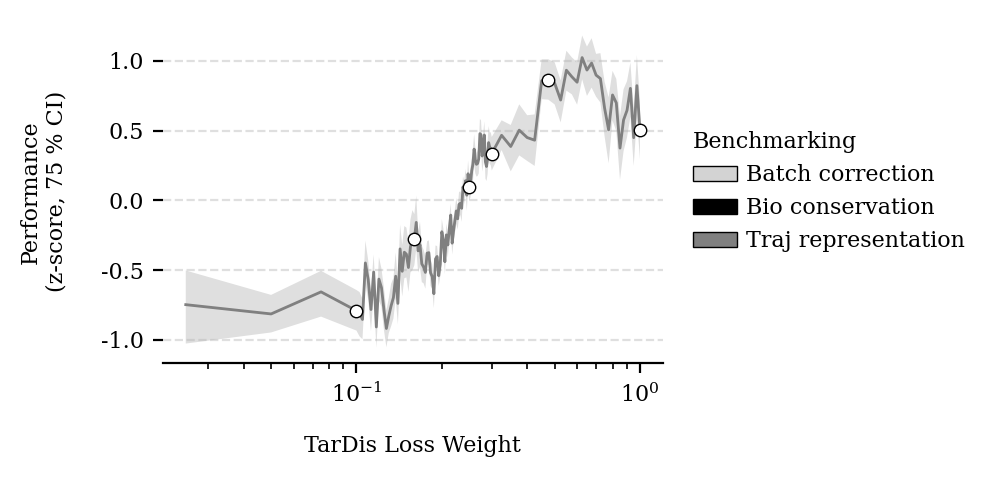

In [16]:
df_result["path"] = "Traj representation"
fig, ax = plot_summary_ci(
    df_result,
    figsize=(6, 2.5),
    x="weight_coef",
    x_label="TarDis Loss Weight",
    legend_title="Benchmarking",
    hue="path", 
    ci=0.75,
    line_width=1.01,
    hue_order=["Batch correction", "Bio conservation", "Traj representation"],
    color = ["lightgray", "black", "gray"]
)
annotate_points_on_line(ax, important_points,
    scatter_kwargs=nice_scatter_kwargs, text_kwargs=False,)
plt.show()

In [9]:
trajectory_object_path = os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_weight_scan_trajectory_object_dose.pkl")
with open(trajectory_object_path, "rb") as _file_definitions:
    trajectory_object = pickle.load(_file_definitions)
little = trajectory_object.get_trajectory("linear", False)

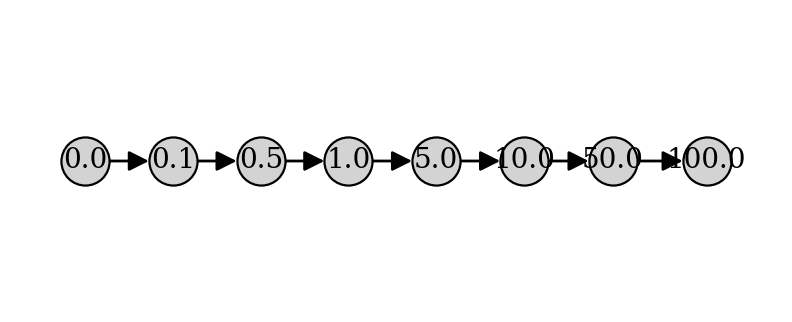

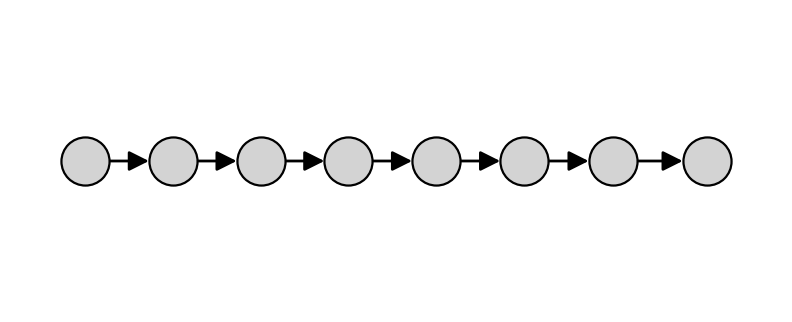

In [14]:
little.plot_trajectory(
    title=None, 
    figsize=(4,1.5),
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    label_offset=0
)
little.plot_trajectory(
    title=None, 
    figsize=(4,1.5),
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    label_offset=800
)

Close-up important points

In [19]:
def cr_calc(adata_cr, root_cell_type, i, label_obs, title, color):
    sc.tl.pca(adata_cr, n_comps=7, svd_solver='arpack')
    sce.tl.palantir(adata_cr, n_components=10, knn=30)

    root_cells = adata_cr.obs_names[adata_cr.obs[label_obs] == root_cell_type]
    if len(root_cells) == 0:
        raise ValueError(f"No cells found with LVL3 == {root_cell_type}")
    start_cell = root_cells[i]
    
    pr_res = sce.tl.palantir_results(
        adata_cr,
        early_cell=start_cell,
        ms_data="X_palantir_multiscale",
        knn=30,
        num_waypoints=1200,
        n_jobs=-1
    )
    adata_cr.obs["palantir_pseudotime"] = pr_res.pseudotime

    # Initialize and compute the PseudotimeKernel
    pk = cr.kernels.PseudotimeKernel(adata_cr, time_key='palantir_pseudotime')
    pk.compute_transition_matrix()

    plt.figure(figsize=(4,3))
    pk.plot_projection(basis='umap', recompute=False, color=color, colorbar=False, title=str(title), ax=plt.gca(), legend_fontsize="medium", legend_loc='none')
    plt.show()

1.0
Sampling and flocking waypoints...
Time for determining waypoints: 0.01712364355723063 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5092862288157145 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


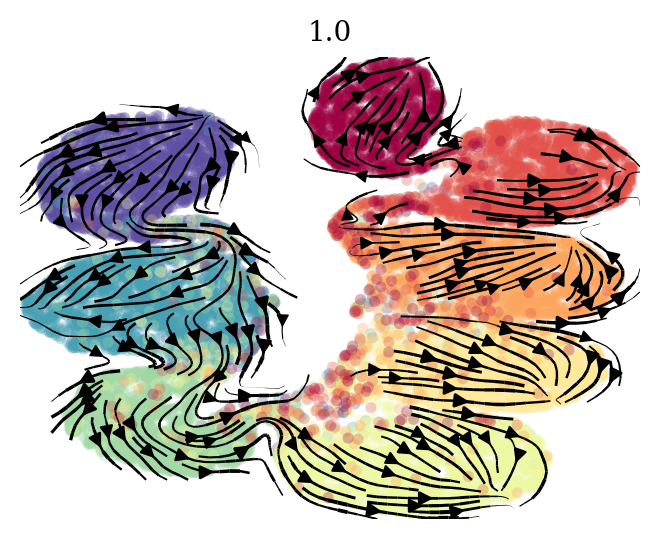

0.475
Sampling and flocking waypoints...
Time for determining waypoints: 0.01760146617889404 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5146774689356486 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


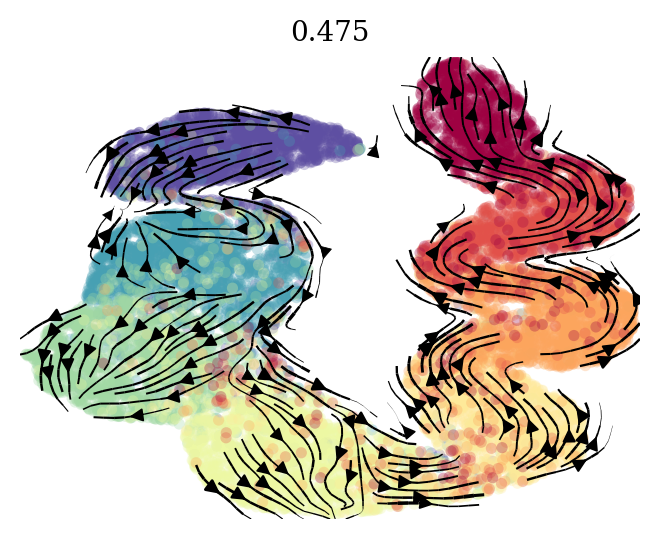

0.3
Sampling and flocking waypoints...
Time for determining waypoints: 0.017165350914001464 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5110840956370036 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


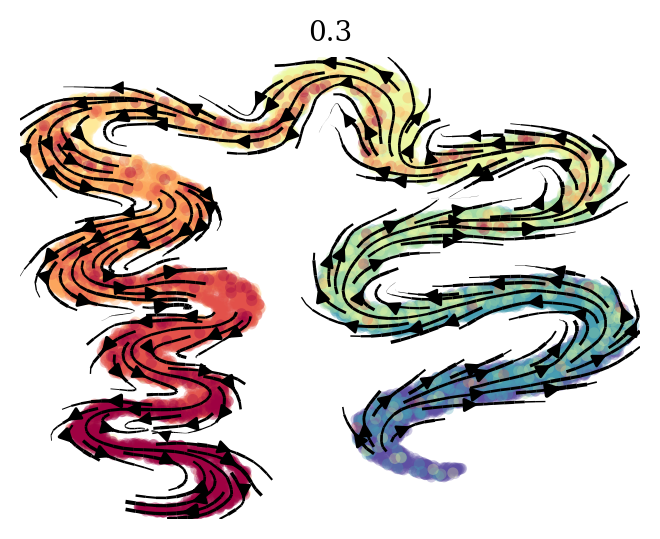

0.25
Sampling and flocking waypoints...
Time for determining waypoints: 0.01723190943400065 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.513010573387146 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


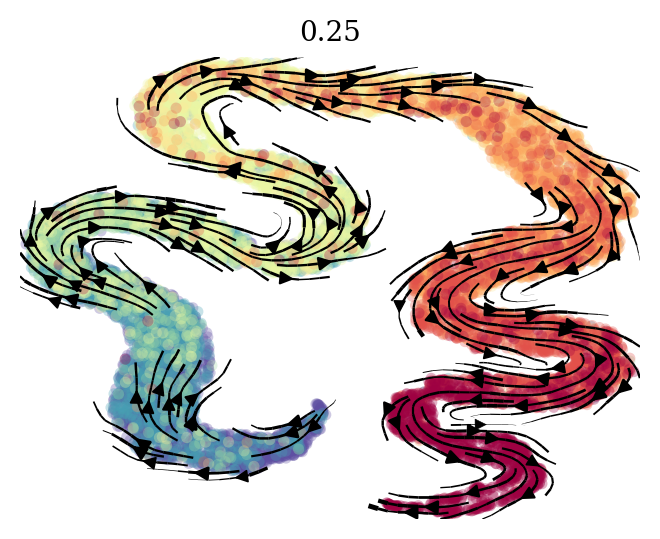

0.16
Sampling and flocking waypoints...
Time for determining waypoints: 0.016561575730641685 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.496184508005778 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


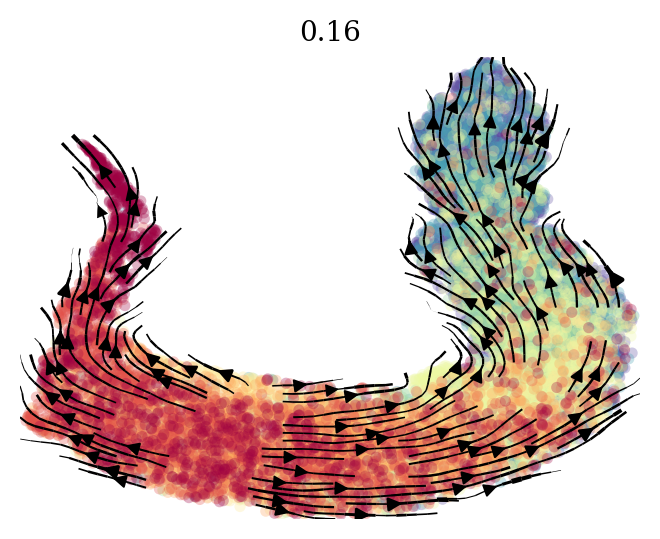

0.1
Sampling and flocking waypoints...
Time for determining waypoints: 0.03834995031356812 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5249062021573384 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9983
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


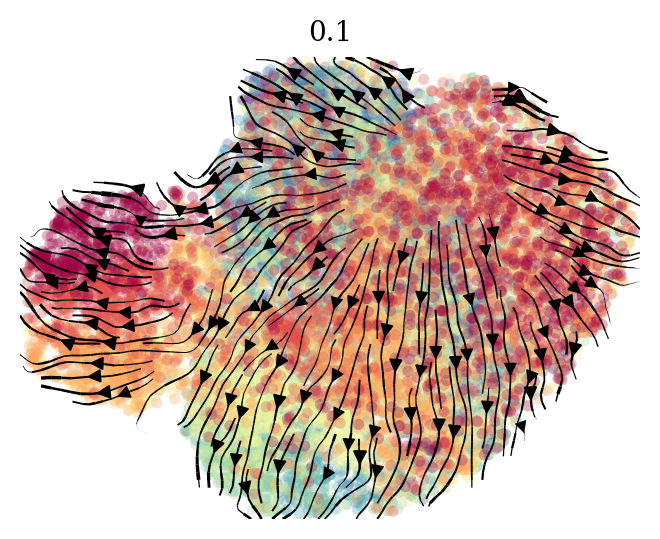

In [20]:
run_id = "tardis_sciplex_dose"

label_obs_column = definitions[run_id]["label_obs_column"]
root_cell_type = '0.0'

for impoint in important_points[::-1]:
    print(impoint)
    latent = ad.read_h5ad(definitions[run_id]["latent_paths"][impoint])
    latent.obs["dose_training"] = latent.obs["dose_training"].astype(float)
    cr_calc(latent, root_cell_type=root_cell_type, label_obs=label_obs_column, title=impoint, color="dose_training", i=0)
    del latent
    gc.collect()

## Complete latent

In [21]:
df_result = (
    df_sctram_by_dataset['tardis_sciplex_whole'].groupby("trajectory", group_keys=False)
      .apply(
          lambda g: normalize_and_align(g, metric_direction_dict),
          include_groups=True
      )
      .reset_index(drop=True)
)
df_result = df_result[df_result["trajectory"] == "complete"]
df_result["trajectory"].unique()

array(['complete'], dtype=object)

In [22]:
important_points = [0.16, 0.2, 0.24, 0.35, 0.6, 1.0]

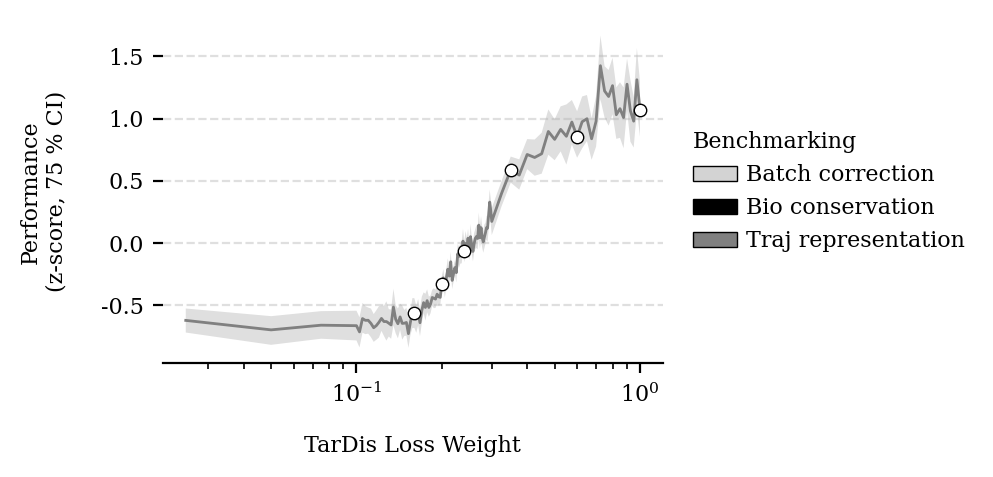

In [23]:
df_result["path"] = "Traj representation"
fig, ax = plot_summary_ci(
    df_result,
    figsize=(6, 2.5),
    x="weight_coef",
    x_label="TarDis Loss Weight",
    legend_title="Benchmarking",
    hue="path", 
    ci=0.75,
    line_width=1.01,
    hue_order=["Batch correction", "Bio conservation", "Traj representation"],
    color = ["lightgray", "black", "gray"]
)
annotate_points_on_line(ax, important_points,
    scatter_kwargs=nice_scatter_kwargs, text_kwargs=False,)
plt.show()

In [10]:
trajectory_object_path = os.path.join(dataset_dir, f"tardis_cpa_sciplex_v2_encode_weight_scan_trajectory_object_whole.pkl")
with open(trajectory_object_path, "rb") as _file_definitions:
    trajectory_object = pickle.load(_file_definitions)
little = trajectory_object.get_trajectory("complete", False)

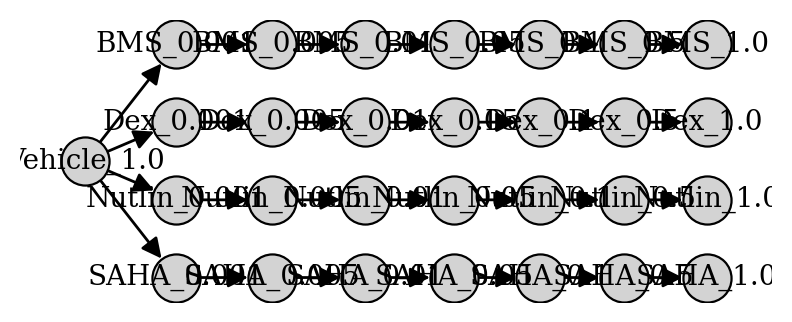

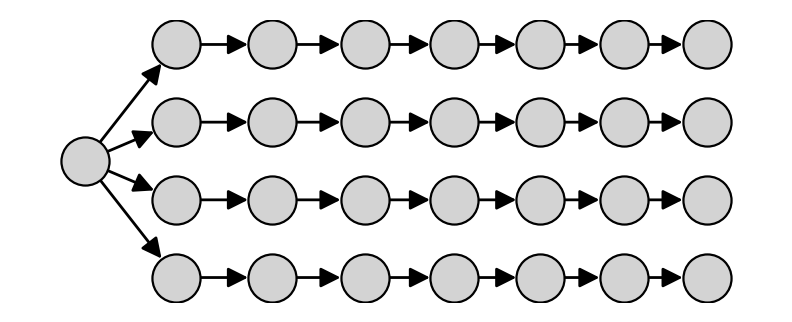

In [11]:
little.plot_trajectory(
    title=None, 
    figsize=(4,1.5),
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    label_offset=0
)
little.plot_trajectory(
    title=None, 
    figsize=(4,1.5),
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    label_offset=800
)

Close-up umaps

In [26]:
def cr_calc(adata_cr, root_cell_type, i, label_obs, title, color):
    sc.tl.pca(adata_cr, n_comps=7, svd_solver='arpack')
    sce.tl.palantir(adata_cr, n_components=10, knn=30)

    root_cells = adata_cr.obs_names[adata_cr.obs[label_obs] == root_cell_type]
    if len(root_cells) == 0:
        raise ValueError(f"No cells found with LVL3 == {root_cell_type}")
    start_cell = root_cells[i]
    
    pr_res = sce.tl.palantir_results(
        adata_cr,
        early_cell=start_cell,
        ms_data="X_palantir_multiscale",
        knn=30,
        num_waypoints=1200,
        n_jobs=-1
    )
    adata_cr.obs["palantir_pseudotime"] = pr_res.pseudotime

    # Initialize and compute the PseudotimeKernel
    pk = cr.kernels.PseudotimeKernel(adata_cr, time_key='palantir_pseudotime')
    pk.compute_transition_matrix()

    plt.figure(figsize=(4,3))
    pk.plot_projection(basis='umap', recompute=False, color=color, colorbar=False, title=str(title), ax=plt.gca(), legend_fontsize="medium", legend_loc='none')
    plt.show()

1.0
Sampling and flocking waypoints...
Time for determining waypoints: 0.016850797335306804 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5082287311553955 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


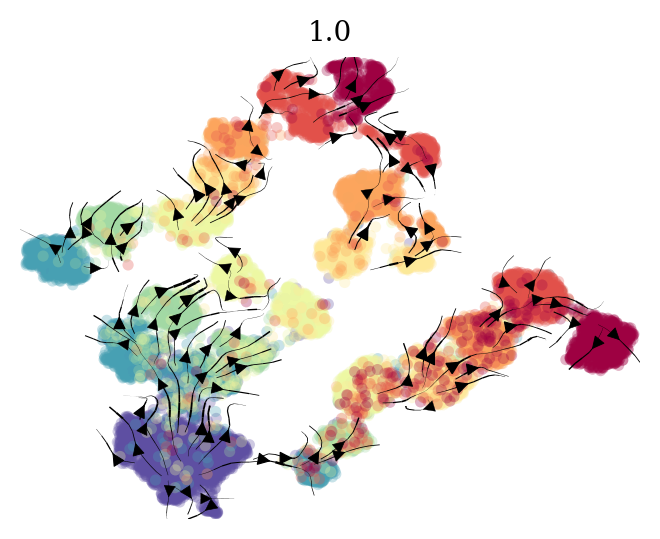

0.6
Sampling and flocking waypoints...
Time for determining waypoints: 0.01684808333714803 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5218013286590576 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


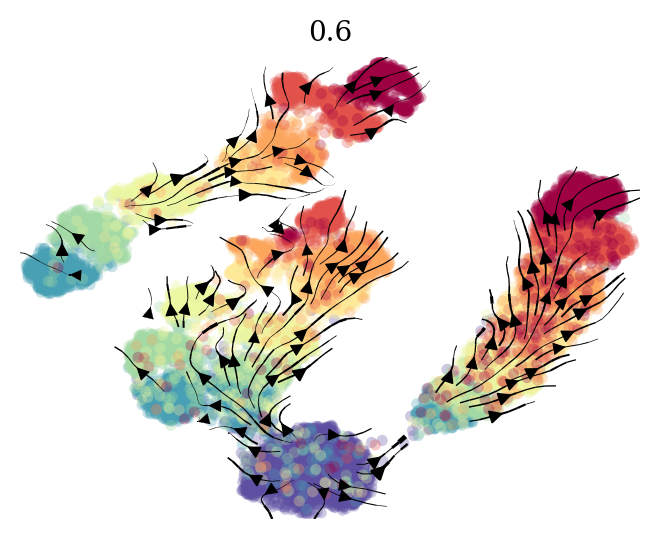

0.35
Sampling and flocking waypoints...
Time for determining waypoints: 0.021048704783121746 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5220203638076782 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


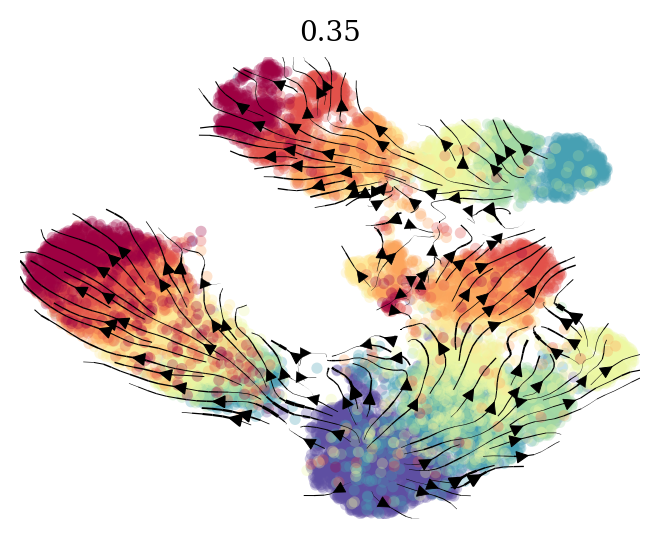

0.24
Sampling and flocking waypoints...
Time for determining waypoints: 0.017903614044189452 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5140600204467773 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9991
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


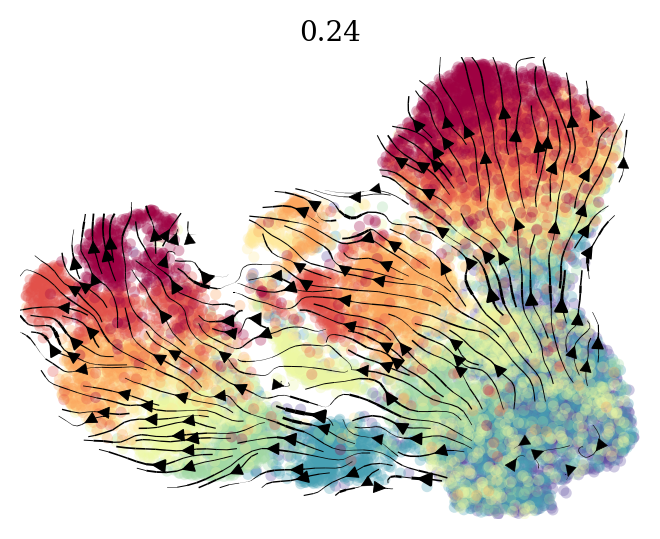

0.2
Sampling and flocking waypoints...
Time for determining waypoints: 0.05057983001073201 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5302459398905436 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


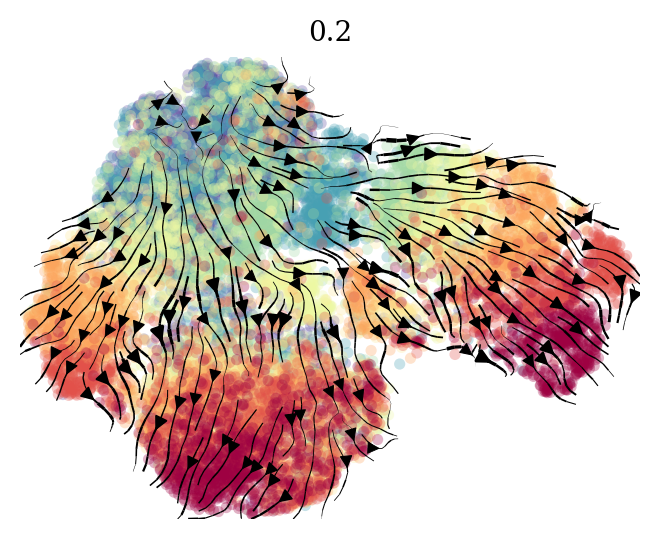

0.16
Sampling and flocking waypoints...
Time for determining waypoints: 0.02499666213989258 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.5340500116348267 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9950
Correlation at iteration 2: 0.9998
Correlation at iteration 3: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/14811 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


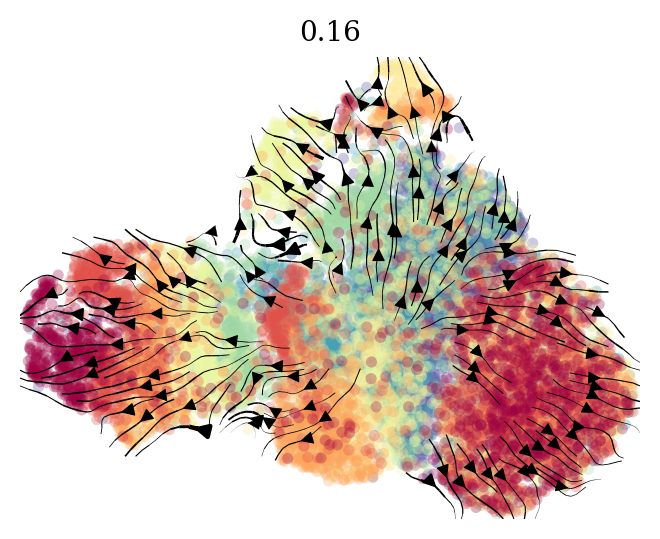

In [27]:
run_id = "tardis_sciplex_whole"

label_obs_column = definitions[run_id]["label_obs_column"]
root_cell_type = 'Vehicle_1.0'

for impoint in important_points[::-1]:
    print(impoint)
    latent = ad.read_h5ad(definitions[run_id]["latent_paths"][impoint])
    latent.obs["dose_training"] = latent.obs["dose_training"].astype(float)
    cr_calc(latent, root_cell_type=root_cell_type, label_obs=label_obs_column, title=impoint, color="dose_training", i=0)
    del latent
    gc.collect()

Colorbar

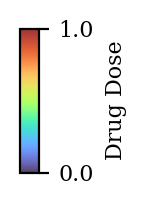

In [28]:
def create_vertical_colorbar(
    label,
    vmin=0.0,
    vmax=1.0,
    cmap='plasma',
    fontsize=10,
    n_ticks=5,
    fig_height=4,
    fig_width=1,
    scale=1.0,
    alpha=1.0
):
    """
    Creates and displays a standalone vertical colorbar.

    Parameters:
    - label:        str, label for the colorbar
    - vmin, vmax:   float, data range
    - cmap:         str, colormap name
    - fontsize:     int, for label & tick labels
    - n_ticks:      int, approx number of ticks to show
    - fig_height:   float, base height in inches
    - fig_width:    float, base width in inches
    - scale:        float, scale factor for overall size
    """
    # 1) Make the ScalarMappable
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    # 2) New figure, scaled
    fig = plt.figure(figsize=(fig_width * scale, fig_height * scale))
    # you can tweak these numbers if you want more/less padding
    cax = fig.add_axes([0.2, 0.05, 0.3, 0.9])

    # 3) Draw the colorbar
    cbar = fig.colorbar(
        sm,
        cax=cax,
        alpha=alpha,
        orientation='vertical'
    )

    # 4) Automatic “nice” locators + re‐draw
    cbar.locator = ticker.MaxNLocator(nbins=n_ticks)
    cbar.update_ticks()

    # 5) Force one‐decimal formatting
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # 6) Label & style
    cbar.set_label(label, fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize)

    plt.show()

create_vertical_colorbar('Drug Dose', cmap="turbo", alpha=0.8, n_ticks=1, fig_height=1, fig_width=0.4, scale=0.8, fontsize=8)

# Exploration UMAPS

In [29]:
# plot_umap_grid(
#     definitions,
#     dataset_key = "tardis_sciplex_dose",
#     color = "dose"
# )

In [30]:
# plot_umap_grid(
#     definitions,
#     dataset_key = "tardis_sciplex_whole",
#     color = "dose"
# )

In [31]:
# plot_umap_grid(
#     definitions,
#     dataset_key = "tardis_sciplex_whole",
#     color = "condition"
# )

In [32]:
1

1